#### Loading packages

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf


#### Setting root directory path

In [5]:
ROOT = r'C:\Users\PC_DS_ECON_5\Desktop\data-analytics-python'


#### Data source used: NLSY97

The NLSY97 is a `longitudinal` (i.e. `panel`) survey of individuals born between 1980 and 1984 (country: U.S.). The first round of data collection took place in 1997 and was followed by additional survey rounds every one or two years.

**Selected data**

For the analysis below, let us use data on the current job (earnings, tenure, hours, occupation, industry) in 2023 and demographic, family background, as well as educational variables.


#### Loading data

Reminder: We need the `pyarrow` package to import a `.parquet` datafile.

In [6]:
nlsy97_current_jobs_2023 = pd.read_parquet(ROOT + '/data/nlsy97_current_jobs_2023.parquet')

#### How much of the gender pay gap can be explained by differences in observable characteristics such as education or occupation?


In a previous session, we saw that there is a gender pay gap: on average, women earn a lower hourly wage than men.

We measured the gender pay gap using the following symmetric formula:

$$
GPG = \frac{\mathbb{E}[hpay \mid gender=\text{Female}] - \mathbb{E}[hpay \mid gender=\text{Male}]}{\max\{\mathbb{E}[hpay \mid gender=\text{Female}], \mathbb{E}[hpay \mid gender=\text{Male}] \}}
$$

Let us compute the exact value of the gender pay gap in our sample:

In [7]:
df = nlsy97_current_jobs_2023.copy()
df = df.loc[df['sample'].eq('Cross-sectional') & df['hpay'].gt(0),:].copy()
female_mean_hpay = df.loc[df['gender'].eq('Female'), 'hpay'].mean()
male_mean_hpay = df.loc[df['gender'].eq('Male'), 'hpay'].mean()

gpg = (female_mean_hpay - male_mean_hpay)/(max(female_mean_hpay, male_mean_hpay))
gpg

np.float64(-0.17123242940098046)

We obtain the same estimated gender pay gap as before:

$$
\widehat{GPG} = \frac{\overline{hpay}_{\mathrm{female}}-\overline{hpay}_{\mathrm{male}}}
{\max\left\{\overline{hpay}_{\mathrm{female}},\overline{hpay}_{\mathrm{male}}\right\}} \approx -0.17 = -17\%
$$

Women earn, on average, about 17% less per hour than men according to this measure.

We can also measure the gender pay gap using a simple linear regression.

To do so, let us first define a dummy variable `female`:

$$
female = 
\begin{cases}
1 & \text{ if } gender = \text{Female}\\
0 & \text{ otherwise }
\end{cases}
$$


In [8]:
df = nlsy97_current_jobs_2023.copy()

df['female'] = np.where(df['gender'].notna(), 
                        np.where(df['gender'].eq('Female'),1,0),
                        pd.NA)
df = df.convert_dtypes()
nlsy97_current_jobs_2023 = df.copy()  

And then let us regress `hpay` on the dummy variable `female`:

$$
hpay = \beta_0 + \beta_1 \cdot female + \varepsilon 
$$

If $\beta_0$ and $\beta_1$ are the OLS coefficients and $\varepsilon$ is the approximation error, then:
 - the mean hourly pay among men is the intercept: $\mathbb{E}[hpay \mid female=0] = \beta_0 $
 - the mean hourly pay among women is the sum of the intercept and the slope coefficient: $\mathbb{E}[hpay \mid female=1] = \beta_0 + \beta_1 $

The reason why we can directly interpret the coefficients in terms of conditional means is that there are **exactly as many parameters ($\beta_0$, $\beta_1$) as conditional means** (`female=1`, `female=0`). In this special case, the regression directly estimates the conditional mean function, that is, the conditional mean of the outcome for each value of the regressor. It is no longer just the best linear approximation to the conditional mean function, because **the best linear approximation and the conditional mean function coincide**. 

Therefore, the slope coefficient is the difference in mean hourly pay between women and men:

$$
\beta_1 = \mathbb{E}[hpay \mid female=1] - \mathbb{E}[hpay \mid female=0]
$$

Our formula above can thus be written as:

$$
GPG = \frac{\beta_1}{\max\{\beta_0 + \beta_1, \beta_0\}}
$$

In [9]:
df = nlsy97_current_jobs_2023.copy()
df = df.loc[df['sample'].eq('Cross-sectional') & df['hpay'].gt(0), :].reset_index(drop=True).copy()

outcome = 'hpay'
regressor = 'female'
formula = outcome + ' ~ ' + regressor 
df = df[[outcome, regressor]].dropna().reset_index().copy()

results = smf.ols(formula=formula, data=df).fit()

results.params

Intercept    41.744334
female       -7.147984
dtype: float64

For our sample, we obtain:

$$
\widehat{hpay}_i = 41.7 - 7.15 \cdot female_i
$$

Interpretation:
 - $\widehat{\beta}_0 = 41.7$: mean hourly pay among men: $\overline{hpay}_{\mathrm{male}}$
 - $\widehat{\beta}_1 = -7.15$: difference in mean hourly pay between women and men: $\overline{hpay}_{\mathrm{female}} - \overline{hpay}_{\mathrm{male}}$

And we get our sample plug-in estimate:

$$
\widehat{GPG} = \frac{\widehat{\beta}_1}{\max\{\widehat{\beta}_0 + \widehat{\beta}_1, \widehat{\beta}_0\}} = \frac{-7.15}{\max\{41.7 - 7.15, 41.7\}} \approx -0.17 = -17\% 
$$


We could get a direct proportional interpretation by regressing log hourly pay `log_hpay` instead of hourly pay:

$$
log(hpay) = \beta_0 + \beta_1 \cdot female + \varepsilon
$$

If $\beta_0$ and $\beta_1$ are the OLS coefficients and $\varepsilon$ is the approximation error, then:
 - the mean log hourly pay among men is the intercept: $\mathbb{E}[log(hpay) \mid female=0] = \beta_0 $
 - the difference in mean log hourly pay among women is the sum of the intercept and the slope coefficient: $\mathbb{E}[log\_hpay \mid female=1] = \beta_0 + \beta_1 $


Therefore, the slope coefficient is the difference in mean hourly pay between women and men:

$$
\beta_1 = \mathbb{E}[log(hpay) \mid female=1] - \mathbb{E}[log(hpay) \mid female=0]
$$


Defining the log hourly pay variable `log_hpay`.  

In [10]:
df = nlsy97_current_jobs_2023.copy()
df['log_hpay'] = pd.NA
valid = df['hpay'].gt(0)
df.loc[valid, 'log_hpay'] = np.log(df.loc[valid, 'hpay'])
df = df.convert_dtypes()
nlsy97_current_jobs_2023 = df.copy()

Running the regression:

In [11]:
df = nlsy97_current_jobs_2023.copy()
df = df.loc[df['sample'].eq('Cross-sectional'), :].reset_index(drop=True).copy()

outcome = 'log_hpay'
regressor = 'female'
formula = outcome + ' ~ ' + regressor 
df = df[[outcome, regressor]].dropna().reset_index().copy()

results = smf.ols(formula=formula, data=df).fit()

results.params

Intercept    3.480250
female      -0.186918
dtype: float64

For our sample, we obtain:

$$
\widehat{\log(hpay)}_i = 3.48 - 0.186 \cdot female_i
$$

Conditional means interpretation:

- $\widehat{\beta}_0 = 3.48$: mean log hourly pay among men:
  $\overline{\log(hpay)}_{\mathrm{male}}$
- $\widehat{\beta}_1 = -0.186$: difference in mean log hourly pay between women and men:
  $\overline{\log(hpay)}_{\mathrm{female}} - \overline{\log(hpay)}_{\mathrm{male}}$

Predicted-value interpretation:

$$
\widehat{\log(hpay)}_i
=
3.48
-
0.186 \cdot female_i
$$

Exponentiating both sides gives the predicted hourly pay:

$$
\widehat{hpay}_i
=
e^{3.48 - 0.186 \cdot female_i}
$$

Taking the proportional difference between the predicted hourly pay of women and men:

$$
\frac{\widehat{hpay}_{\mathrm{female}}
-
\widehat{hpay}_{\mathrm{male}}}
{\widehat{hpay}_{\mathrm{male}}}
=
\frac{
e^{3.48-0.186\cdot1}
-
e^{3.48-0.186\cdot0}
}
{
e^{3.48-0.186\cdot0}
}
$$

Using the properties of exponentiation:

$$
\frac{\widehat{hpay}_{\mathrm{female}}
-
\widehat{hpay}_{\mathrm{male}}}
{\widehat{hpay}_{\mathrm{male}}}
=
e^{-0.186}-1
=
-0.1697
\approx
-17\%.
$$

Because the exponential function is non-linear, the proportional difference between exponentiated conditional mean log hourly pay is generally not identical to the proportional difference between conditional mean hourly pay. In this example, however, the numerical difference is very small.

This is why

- the proportional difference in exponentiated conditional mean log hourly pay:

$$
\frac{
e^{\overline{\log(hpay)}_{\mathrm{female}}}
-
e^{\overline{\log(hpay)}_{\mathrm{male}}}
}
{
e^{\overline{\log(hpay)}_{\mathrm{male}}}
}
=
-0.1697,
$$

and

- the proportional difference in conditional mean hourly pay:

$$
\frac{
\overline{hpay}_{\mathrm{female}}
-
\overline{hpay}_{\mathrm{male}}
}
{
\overline{hpay}_{\mathrm{male}}
}
=
-0.1712
$$

are often treated as approximately equivalent in practice.

##### From unconditional to conditional gender pay gaps

Up to this point, the object of interest has been the **unconditional** difference in mean hourly pay between men and women.

This unconditional gap may itself be of interest for many reasons (e.g. savings, pensions, bargaining power within the household).

However, we may also wish to understand **how much of this gap can be attributed to observable characteristics**.

Simple examples are that men and women are not equally likely

- to work in the same occupations;
- to have the same educational attainment;
- etc.

In other words, **composition effects** may contribute to the unconditional gender pay gap.

For example, we may be interested in the gender pay gap **while holding occupation constant**, or **while holding education constant**.

This is precisely what **multiple linear regression** is useful for.

Let us start by controlling for education.

Education is measured by the categorical variable `educ_cat`, which has four categories.

We include three education dummy variables, using the fourth category `Less than High School` as the reference category:

$$
\begin{array}{rcl}
log(hpay) &=&
\beta_0
+ \beta_1 \cdot female
+ \delta_{HS} \cdot \mathbb{1}[educ\_cat=\text{High School}]\ + \\ \\
&& \ \
+\ \delta_{SC} \cdot \mathbb{1}[educ\_cat=\text{Some College}]
+ \delta_{BP} \cdot \mathbb{1}[educ\_cat=\text{Bachelor Plus}]
+ \varepsilon.
\end{array}
$$

Here, we can no longer interpret the coefficients as conditional means. The reason is that the number of parameters (5 coefficients: $\beta_0$, $\beta_1$, $\delta_{HS}$, $\delta_{SC}$, $\delta_{BP}$) is smaller than the number of conditional means to be estimated (2 genders × 4 education categories = 8 conditional means).

The regression therefore imposes restrictions on the conditional mean function.

Unlike the previous regression, this specification is therefore only the best linear approximation to the conditional mean function.

The variable `educ_cat` is already stored as an ordered categorical variable:

In [12]:
nlsy97_current_jobs_2023['educ_cat'].dtype

CategoricalDtype(categories=['Less than High School', 'High School', 'Some College',
                  'Bachelor Plus'],
, ordered=True, categories_dtype=str)

As a result, it can be included directly in the statsmodels formula interface and the first category in the specified category ordering is automatically used as the reference category.

In [13]:
df = nlsy97_current_jobs_2023.copy()

df['educ_cat'].dtype


outcome = 'log_hpay'
regressors = ['female', 'educ_cat']
formula = 'log_hpay ~ female + educ_cat'

df = df[[outcome] + regressors].dropna().reset_index().copy()

results = smf.ols(formula=formula, data=df).fit()

results.params

Intercept                    3.073335
educ_cat[T.High School]      0.177480
educ_cat[T.Some College]     0.331898
educ_cat[T.Bachelor Plus]    0.773282
female                      -0.244247
dtype: float64

In our sample, the estimated equation is:

$$
\begin{array}{rcl}
\widehat{log(hpay)} &=&
3.073
- 0.244 \cdot female
+ 0.177 \cdot \mathbb{1}[educ\_cat=\text{High School}] \ + \\
\\
&& \ \ 
+\ 0.332 \cdot \mathbb{1}[educ\_cat=\text{Some College}]
+ 0.773 \cdot \mathbb{1}[educ\_cat=\text{Bachelor Plus}]
\end{array}
$$

Using the predicted value interpretation together with the log-level interpretation:

- $\widehat{\beta}_0 = 3.073$: predicted log hourly pay for men ($female=0$) without a high school degree (the reference category for educational attainment)
- $\widehat{\beta}_1 = -0.244$: holding education constant, women are predicted to earn 21.7% less per hour than men on average ($e^{-0.244}-1 \approx -0.217 = -21.7\%$)
- $\widehat{\delta}_{HS} = 0.177$: holding gender constant, individuals whose highest level of education is a high school degree are predicted to earn 19.4% more per hour on average than individuals without a high school degree ($e^{0.177}-1 \approx 0.194 = 19.4\%$)
- $\widehat{\delta}_{SC} = 0.332$: holding gender constant, individuals who have attended college but do not have a Bachelor's degree are predicted to earn 39.4% more per hour on average than individuals without a high school degree ($e^{0.332}-1 \approx 0.394 = 39.4\%$)
- $\widehat{\delta}_{BP} = 0.773$: holding gender constant, individuals who have a Bachelor's degree or higher are predicted to earn 117% more per hour on average than individuals without a high school degree ($e^{0.773}-1 \approx 1.17 = 117\%$)

In [14]:
for coef in results.params.index.drop(['Intercept']):
    print(coef, np.exp(results.params[coef]) - 1)

educ_cat[T.High School] 0.1942046929469492
educ_cat[T.Some College] 0.39361024922322607
educ_cat[T.Bachelor Plus] 1.1668667555865238
female -0.21670573836002316


Overall, the gender pay gap seems to be stronger when controlling for education (21% versus 17%). 

In the previous regression, there were however restrictions: returns to education were the same within each gender and gender pay gaps were the same within each education category. 

Are there higher returns to education for males? What part of the gender pay gap is composition?

Let us run a fully flexible specification, estimating returns to educational attainment separately for each gender.

The regression equation now contains a full interaction of both categorical variables. We should have now eight parameters:

$$
\begin{array}{rcl}
log(hpay) &=&
\beta^{\mathrm{male}}_{0}
+ \gamma^{\mathrm{female}}_{0} \cdot female
+ \delta^{\mathrm{male}}_{HS} \cdot \mathbb{1}[educ\_cat=\text{High School}]\ + \gamma^{\mathrm{female}}_{HS} \cdot female \cdot \mathbb{1}[educ\_cat=\text{High School}]  \ + \\ \\
&& \ \
+\ \delta^{\mathrm{male}}_{SC} \cdot \mathbb{1}[educ\_cat=\text{Some College}] + \gamma^{\mathrm{female}}_{SC} \cdot female \cdot \mathbb{1}[educ\_cat=\text{Some College}]  \ + \\ \\
&& \ \
+ \delta^{\mathrm{male}}_{BP} \cdot \mathbb{1}[educ\_cat=\text{Bachelor Plus}] + \gamma^{\mathrm{female}}_{BP} \cdot female \cdot \mathbb{1}[educ\_cat=\text{Bachelor Plus}]
+ \varepsilon.
\end{array}
$$

Because we are not just approximating but exactly matching the conditional mean function $\mathbb{E}[log\_hpay \mid female, educ\_cat]$, we have a perfect correspondence between the coefficients and the conditional means:

$$
\begin{array}{rcl}
\mathbb{E}[log\_hpay \mid female=0, educ\_cat=\text{Less than High School}]  &=& \beta^{\mathrm{male}}_{0}  \\ \\
 \mathbb{E}[log\_hpay \mid female=1, educ\_cat=\text{Less than High School}] &=& \beta^{\mathrm{male}}_{0} + \gamma^{\mathrm{female}}_{0} \\ \\
\mathbb{E}[log\_hpay \mid female=0, educ\_cat=\text{High School}]  &=& \beta^{\mathrm{male}}_{0} + \delta^{\mathrm{male}}_{HS} \\ \\
\mathbb{E}[log\_hpay \mid female=1, educ\_cat=\text{High School}] &=& \beta^{\mathrm{male}}_{0} + \gamma^{\mathrm{female}}_{0} + \delta^{\mathrm{male}}_{HS} + \gamma^{\mathrm{female}}_{HS} \\ \\
\mathbb{E}[log\_hpay \mid female=0, educ\_cat=\text{Some College}] &=& \beta^{\mathrm{male}}_{0} + \delta^{\mathrm{male}}_{SC}  \\ \\
\mathbb{E}[log\_hpay \mid female=1, educ\_cat=\text{Some College}] &=& \beta^{\mathrm{male}}_{0} + \gamma^{\mathrm{female}}_{0} + \delta^{\mathrm{male}}_{SC} + \gamma^{\mathrm{female}}_{SC}  \\ \\
\mathbb{E}[log\_hpay \mid female=0, educ\_cat=\text{Bachelor Plus}] &=& \beta^{\mathrm{male}}_{0} + \delta^{\mathrm{male}}_{BP} \\ \\
\mathbb{E}[log\_hpay \mid female=1, educ\_cat=\text{Bachelor Plus}] &=& \beta^{\mathrm{male}}_{0} + \gamma^{\mathrm{female}}_{0} + \delta^{\mathrm{male}}_{BP} + \gamma^{\mathrm{female}}_{BP}
\end{array}
$$


Let us run the regression above and let us also count the shares of each educational category within each gender: 

In [15]:
df = nlsy97_current_jobs_2023.copy()

df['educ_cat'].dtype


outcome = 'log_hpay'
regressors = ['female', 'educ_cat']
formula = 'log_hpay ~ female * educ_cat'

df = df[[outcome] + regressors].dropna().reset_index().copy()
results = smf.ols(formula=formula, data=df).fit()
results.params




Intercept                           3.061860
educ_cat[T.High School]             0.222978
educ_cat[T.Some College]            0.348877
educ_cat[T.Bachelor Plus]           0.761364
female                             -0.216966
female:educ_cat[T.High School]     -0.106980
female:educ_cat[T.Some College]    -0.038017
female:educ_cat[T.Bachelor Plus]    0.013213
dtype: float64

Let us construct the returns by group and let us also count the share of individuals by education group within each gender:
 - The returns for females can be obtained as follows: 
    - $\delta^{\mathrm{female}}_{HS} = \delta^{\mathrm{male}}_{HS} + \gamma^{\mathrm{female}}_{HS}$
    - $\delta^{\mathrm{female}}_{SC} = \delta^{\mathrm{male}}_{SC} + \gamma^{\mathrm{female}}_{SC}$
    - $\delta^{\mathrm{female}}_{BP} = \delta^{\mathrm{male}}_{BP} + \gamma^{\mathrm{female}}_{BP}$


In [16]:
educ_cat_reference = 'Less than High School'

coeff = pd.DataFrame({'value': results.params}).reset_index().rename(columns={'index': 'name'})
coeff['educ_cat'] = coeff['name'].str.split('.', expand=True)[1]
coeff['educ_cat'] = coeff['educ_cat'].str.removesuffix(']')
coeff['female'] = coeff['name'].str.match('female').astype(int)
coeff = coeff.convert_dtypes()
coeff.loc[coeff['educ_cat'].isna(), 'educ_cat'] = educ_cat_reference
coeff = coeff.drop(columns='name').copy()

coeff_wide = coeff.pivot_table(columns='female', values='value', index='educ_cat').reset_index().sort_values('educ_cat').reset_index(drop=True).copy()
# coeff_wide = coeff_wide.rename(columns={0: 'male', 1: 'female'})

coeff_wide[1] = coeff_wide[0] + coeff_wide[1]
coeff_wide.loc[coeff_wide['educ_cat'].eq(educ_cat_reference), 0] = 0
coeff_wide.loc[coeff_wide['educ_cat'].eq(educ_cat_reference), 1] = 0
returns = coeff_wide.melt(id_vars='educ_cat', var_name='female', value_name='value').sort_values(['female', 'educ_cat']).reset_index(drop=True).copy()

returns = returns.astype({
                            'educ_cat': df['educ_cat'].dtype,
                            'female': df['female'].dtype,
                        }).sort_values(['female', 'educ_cat']).reset_index(drop=True).copy()
returns = returns.rename(columns={'value': 'relative'})




educ_cat_shares = df.groupby('female').value_counts(normalize=True, subset=['educ_cat']).reset_index().copy()

reference_cat_vals = coeff.loc[coeff['educ_cat'].eq(educ_cat_reference), ['female', 'value']].copy()
reference_cat_vals.loc[coeff['female'].eq(1), ['value']] = reference_cat_vals['value'].sum()
reference_cat_vals = reference_cat_vals.rename(columns={'value': 'base'})

returns = pd.merge(left=returns,
         right=reference_cat_vals,
         on=['female'],
         how='left')

returns['absolute'] = returns['base'] + returns['relative']

returns

educ_cat_shares


,female,educ_cat,proportion
0,0,Bachelor Plus,0.291441
1,0,Some College,0.269772
2,0,High School,0.227880
3,0,Less than High School,0.210906
4,1,Bachelor Plus,0.396552
5,1,Some College,0.282328
6,1,High School,0.168822
7,1,Less than High School,0.152299


Plotting the returns to education by gender and education category:

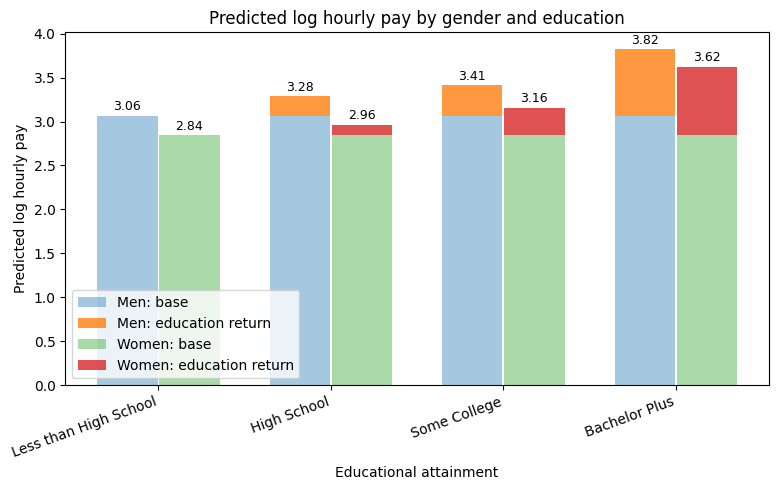

In [17]:
plot_df = returns.copy()

gender_labels = {0: 'Men', 1: 'Women'}
plot_df['gender'] = plot_df['female'].map(gender_labels)

education_order = df['educ_cat'].cat.categories
plot_df['educ_cat'] = plot_df['educ_cat'].astype(df['educ_cat'].dtype)

x_base = np.arange(len(education_order))
dodge = 0.18
bar_width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

for female_value, offset in [(0, -dodge), (1, dodge)]:
    tmp = (
        plot_df
        .loc[plot_df['female'].eq(female_value)]
        .sort_values('educ_cat')
    )

    x = x_base + offset
    label = gender_labels[female_value]

    ax.bar(
        x=x,
        height=tmp['base'],
        width=bar_width,
        label=f'{label}: base',
        alpha=0.4,
    )

    ax.bar(
        x=x,
        height=tmp['relative'],
        bottom=tmp['base'],
        width=bar_width,
        label=f'{label}: education return',
        alpha=0.8,
    )

    for xi, y in zip(x, tmp['absolute']):
        ax.text(
            xi,
            y + 0.03,
            f'{y:.2f}',
            ha='center',
            va='bottom',
            fontsize=9,
        )

ax.set_xticks(x_base)
ax.set_xticklabels(education_order, rotation=20, ha='right')


ax.set_ylabel('Predicted log hourly pay')
ax.set_xlabel('Educational attainment')
ax.set_title('Predicted log hourly pay by gender and education')

ax.legend()
fig.tight_layout()
plt.show()

Plotting the number of individuals by gender and education category:

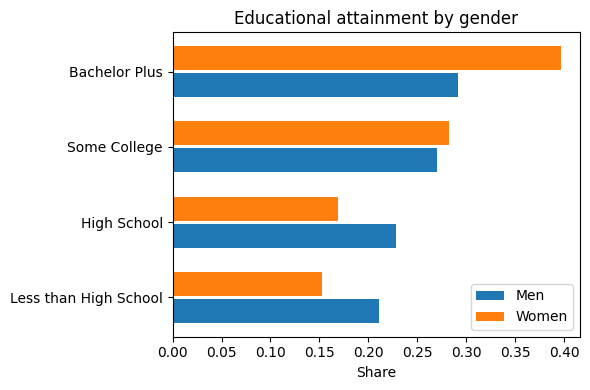

In [18]:
shares = (
    educ_cat_shares
    .sort_values(['female', 'educ_cat'])
    .copy()
)

education_order = df['educ_cat'].cat.categories
shares['educ_cat'] = shares['educ_cat'].astype(df['educ_cat'].dtype)

y = np.arange(len(education_order))
dodge = 0.18

fig, ax = plt.subplots(figsize=(6, 4))

for female, offset, label in [
    (0, -dodge, 'Men'),
    (1,  dodge, 'Women')
]:
    tmp = shares.loc[shares['female'].eq(female)].sort_values('educ_cat')

    ax.barh(
        y + offset,
        tmp['proportion'],      # oder 'prop', je nach Name
        height=0.32,
        label=label,
    )

ax.set_yticks(y)
ax.set_yticklabels(education_order)
ax.set_xlabel('Share')
ax.set_title('Educational attainment by gender')
ax.legend()

plt.tight_layout()

The overall picture is mixed. At the intermediate educational levels, men are slightly overrepresented and the gender pay gaps are somewhat larger. At the two extremes of the education distribution, women are slightly overrepresented and the gender pay gaps are somewhat smaller.

The contribution of educational attainment to the overall gender pay gap is therefore not immediately clear from the figure alone.

One thing appears to be clear: educational attainment cannot fully explain the gender pay gap, because substantial gender pay gaps remain within every education category.

Let us now investigate whether occupational sorting can explain part of the gender pay gap. We start with including dummy variables for all occupation groups except one as control variables:

$$
\begin{array}{rcl}
log(hpay) &=& \beta_0 + \beta_1 \cdot female + \displaystyle\sum_{j \in \text{All occupations except reference}} \delta_j \cdot \mathbb{1}[occupation\_group = j]
\end{array}
$$

Let us restrict the analysis to the representative sample and let us count the number and the share of individuals belonging to each occupation group, separately for each gender.    

In [20]:
df = nlsy97_current_jobs_2023.copy()
# representative sample
df = df.loc[df['sample'].eq('Cross-sectional'),:].copy()
# within each gender
# proportion / number of individuals belonging to each occupation
occ_cat_shares = (
    df
        # within gender
        .groupby('gender')
        # proportion of individuals per occupation
        .value_counts(normalize=True, subset=['occupation_group'])
        .reset_index()
        # reshaping the results to have the proportions for each gender for the same occupation side by side 
        # reshaping from long to wide
        .pivot_table(values='proportion', columns='gender', index = 'occupation_group')
        .reset_index()
        .convert_dtypes()
        .copy()
)
occ_cat_shares.columns.name = None
occ_cat_shares
occ_cat_n = (
    df
        .groupby('gender')
        .value_counts(normalize=False, subset=['occupation_group'])
        .reset_index()
        .pivot_table(values='count', columns='gender', index = 'occupation_group')
        .reset_index()
        .convert_dtypes()
        .copy()
)

occ_cat_n.columns.name = None
occ_cat_n


,occupation_group,Female,Male
0,"Executive, administrative and managerial",312,349
1,Management related,134,110
2,Mathematical and computer scientists,29,101
3,"Engineers, architects, and surveyors",9,32
4,Engineering technicians,1,14
5,Physical scientists,8,13
6,Social scientists,12,9
7,Science technicians,0,4
8,"Counselors, social and religious workers",75,24
9,Legal occupations,32,22


Let us merge the occupation groups with less than five women or less than five men into an 'Other' category.

In [21]:
df = nlsy97_current_jobs_2023.copy()

df = df.loc[df['sample'].eq('Cross-sectional'),:].copy()

# which occupations to group together
occ_to_other = occ_cat_n.loc[
    # less than five women or less than five men
    occ_cat_n["Female"].lt(5) | occ_cat_n["Male"].lt(5),
    "occupation_group",
]
# occupation_group_tr
df["occupation_group_tr"] = np.where(
    # if the occupation is to be grouped together
    df["occupation_group"].isin(occ_to_other),
    # set the name of the occupation to "Other"
    "Other",
    # otherwise: use the original name
    df["occupation_group"],
)

Let us run the regression with the transformed variable:

In [22]:
# statsmodels formula api 
outcome = 'log_hpay'
regressors = ['female', 'occupation_group_tr']
# formula = 'log_hpay ~ female + occupation_group_tr' --> no direct control over the reference category 
# specifying the reference category:
formula = 'log_hpay ~ female + C(occupation_group_tr, Treatment(reference="Food preparation and serving"))'

df_reg = df[[outcome] + regressors].dropna().reset_index(drop=True).copy()

results = smf.ols(formula=formula, data=df_reg).fit()

print(results.params.to_string(float_format='{:.6f}'.format))

Intercept                                                                                                                  2.652015
C(occupation_group_tr, Treatment(reference="Food preparation and serving"))[T.ACS special codes]                           0.457133
C(occupation_group_tr, Treatment(reference="Food preparation and serving"))[T.Cleaning and building service]               0.447829
C(occupation_group_tr, Treatment(reference="Food preparation and serving"))[T.Construction trades]                         0.749455
C(occupation_group_tr, Treatment(reference="Food preparation and serving"))[T.Counselors, social and religious workers]    0.970820
C(occupation_group_tr, Treatment(reference="Food preparation and serving"))[T.Education, training and library]             0.622741
C(occupation_group_tr, Treatment(reference="Food preparation and serving"))[T.Engineers, architects, and surveyors]        1.433284
C(occupation_group_tr, Treatment(reference="Food preparation and serving"))[

In [ ]:
(np.exp(results.params['female']) - 1) * 100


Even after controlling for occupation, the coefficient remains essentially the same as before:

$$
\begin{array}{rcl}
\widehat{log(hpay)}_{i} &=& 2.65 - 0.196 \cdot female_{i} + \displaystyle\sum_{j \in \text{All occupations except reference}} \widehat{\delta}_j \cdot \mathbb{1}[occupation\_group\_tr_{i} = j]
\end{array}
$$

such that the interpretation of $\widehat{\beta}_1 \approx -0.196$:
- Holding occupation group constant, women are predicted to earn on average approximately $ e^{-0.196}-1 \approx -17.8 \% $ less per hour than men.
- Comparing women and men within the same occupation group, women are predicted to earn, on average, approximately $ e^{-0.196}-1 \approx -17.8 \% $ less per hour than men.


#### Oaxaca-Blinder decomposition

The objective is to decompose the overall gender pay gap into two components:

- the component due to the different allocation of women and men across occupations (**composition effect**);
- the remaining component due to differences in the estimated wage structure (**returns effect**).

The idea is closely related to the educational attainment example above.

The main difference is that occupations have many categories and cannot be naturally ordered.

Rather than inspecting the gender pay gap within every occupation separately, we would like to summarize the contribution of occupational sorting with a single measure.

To do so, we estimate the following regression model with only occupation dummies (this time without an intercept):

$$
\begin{array}{rcl}
log(hpay) &=& \displaystyle\sum_{j \in \text{All occupations}} \rho_j \cdot \mathbb{1}[occupation\_group\_tr = j]
\end{array}
$$

separately for three sub-samples:

- **Pooled regression:** regression estimated for the full sample.
- **Women's regression:** regression estimated only for women.
- **Men's regression:** regression estimated only for men.

The $\rho_j$ coefficients correspond to the mean log hourly pay for occupation group $j$.

The average predicted log hourly pay obtained by combining the occupation shares from sub-sample $P$ with the regression coefficients estimated from sub-sample $R$:

$$
\begin{array}{rcl}
\overline{\widehat{log(hpay)}}^{R}_{P} &=& \displaystyle\sum_{j \in \text{All occupations}}\ \ \ \ \ \ \underbrace{\widehat{\rho}^{R}_j}_{\mathclap{\substack{\text{average}\\ \text{log hourly pay}\\ \text{for occupation} j\\ \text{in sub-sample } R}}}\ \ \ \ \ \ \cdot \ \ \ \ \ \ \underbrace{\widehat{p}^{P}_{j}}_{\mathclap{\substack{\text{proportion}\\ \text{belonging to}\\ \text{occupation } j \\ \text{in sub-sample } P}}}
\end{array}
$$

One version of the Oaxaca-Blinder decomposition is then given by

$$
\begin{array}{rcl}
(\overline{log(hpay)}_{Women})
-
(\overline{log(hpay)}_{Men})
&=&
\underbrace{
\left(
\overline{\widehat{log(hpay)}}^{R=Pooled}_{P=Women}
-
\overline{\widehat{log(hpay)}}^{R=Pooled}_{P=Men}
\right)
}_{\substack{\text{explained by occupational sorting}\\ \text{composition effect}}} 
\ +
\\
\\
\\
&&\ +\ 
\underbrace{
\left[
\left(
\overline{\widehat{log(hpay)}}^{R=Women}_{P=Women}
-
\overline{\widehat{log(hpay)}}^{R=Pooled}_{P=Women}
\right)
+
\left(
\overline{\widehat{log(hpay)}}^{R=Pooled}_{P=Men}
-
\overline{\widehat{log(hpay)}}^{R=Men}_{P=Men}
\right)
\right]
}_{\substack{\text{not explained by occupational sorting}\\ \text{returns effect}}}
\end{array}
$$


The first term measures the part of the gender pay gap that can be explained by differences in the occupational distribution of women and men.

The remaining terms measure the part of the gap that cannot be explained by occupational sorting and is instead attributed to differences in the estimated wage structure.

In [23]:
outcome = 'log_hpay'
regressors = ['occupation_group_tr']
# '0 +' --> indicates: no intercept
formula = 'log_hpay ~ 0 + occupation_group_tr'

Pooled regression:

In [24]:
# keep observations with non-missing values 
df_pooled = df[[outcome] + regressors].dropna().reset_index(drop=True).copy()
pooled_reg = smf.ols(formula=formula, data=df_pooled).fit()

Regression for women:

In [25]:
df_women = df.loc[df['gender'].eq('Female'),:].copy()
df_women = df_women[[outcome] + regressors].dropna().reset_index(drop=True).copy()
women_reg = smf.ols(formula=formula, data=df_women).fit()

Regression for men:

In [26]:
df_men = df.loc[df['gender'].eq('Male'),:].copy()
df_men = df_men[[outcome] + regressors].dropna().reset_index(drop=True).copy()
men_reg = smf.ols(formula=formula, data=df_men).fit()

Average prediction for women based on pooled-regression, $\ \ \overline{\widehat{log(hpay)}}^{R=Pooled}_{P=Women}$:

In [27]:
mean_pred_women_based_on_pooled = pooled_reg.predict(df_women).mean()

Average prediction for men based on pooled-regression, $\ \ \overline{\widehat{log(hpay)}}^{R=Pooled}_{P=Men}$:

In [28]:
mean_pred_men_based_on_pooled = pooled_reg.predict(df_men).mean()

Average prediction for women based on women-regression, $\ \ \overline{\widehat{log(hpay)}}^{R=Women}_{P=Women}$:

In [29]:
# should be equal to the average log hourly pay for women
mean_pred_women_based_on_women = women_reg.predict(df_women).mean()

Average prediction for men based on men-regression, $\ \ \overline{\widehat{log(hpay)}}^{R=Men}_{P=Men}$:

In [30]:
# should be equal to the average log hourly pay for men
mean_pred_men_based_on_men = men_reg.predict(df_men).mean()

Total gap:

In [31]:
total_gap = (mean_pred_women_based_on_women - mean_pred_men_based_on_men)
total_gap

np.float64(-0.18135635039105225)

Explained by occupational sorting (composition effect):

In [32]:
composition_effect = mean_pred_women_based_on_pooled - mean_pred_men_based_on_pooled
composition_effect

np.float64(-0.02893340317523263)

Gap not explained by occupational sorting (returns effect):

In [33]:
returns_effect = (mean_pred_women_based_on_women - mean_pred_women_based_on_pooled) + (mean_pred_men_based_on_pooled - mean_pred_men_based_on_men)
returns_effect

np.float64(-0.15242294721581962)

Oaxaca-Blinder decomposition:

$$
\underbrace{\text{Total gap}}_{\approx -0.181} = \underbrace{\text{Explained by occupational sorting}}_{\approx -0.029} + \underbrace{\text{Not explained by occupational sorting}}_{\approx -0.152}
$$

In this simple setting, the returns effect is the remaining part of the gender pay gap after accounting for occupational composition. It reflects differences in average wages within occupations as well as any other factors not explained by occupational sorting.